# Self-Attention — Implementation & Verification

This notebook covers the **attention implementation** part of Lab 5:

1. **Single-head self-attention** — we implement the module from scratch and verify it against PyTorch's `nn.MultiheadAttention` (with 1 head).
2. **Multi-head self-attention** — we extend the implementation to multiple heads and verify it the same way.

All modules live in `attention.py` so they can be reused elsewhere.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from attention import SelfAttention, MultiHeadSelfAttention

## 1. Single-Head Self-Attention

Given an input $X \in \mathbb{R}^{B \times T \times D}$, single-head self-attention computes:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

$$S = \frac{QK^\top}{\sqrt{D}}, \quad A = \text{softmax}(S), \quad Y = AV$$

Finally an output projection is applied: $\text{out} = YW_O$.

Our `SelfAttention` class stores the attention weights in `self.attention_weights` so we can inspect them later.

In [2]:
torch.manual_seed(42)

B, T, D = 2, 10, 64
x = torch.randn(B, T, D)

sa = SelfAttention(embed_dim=D)
y = sa(x)

print(f"Input shape:            {x.shape}")
print(f"Output shape:           {y.shape}")
print(f"Attention weights shape: {sa.attention_weights.shape}")

assert y.shape == (B, T, D), "Output shape mismatch!"
assert sa.attention_weights.shape == (B, T, T), "Attention weights shape mismatch!"

row_sums = sa.attention_weights.sum(dim=-1)
print(f"\nAttention row sums (should be ~1.0): min={row_sums.min():.6f}, max={row_sums.max():.6f}")

Input shape:            torch.Size([2, 10, 64])
Output shape:           torch.Size([2, 10, 64])
Attention weights shape: torch.Size([2, 10, 10])

Attention row sums (should be ~1.0): min=1.000000, max=1.000000


### 1.1 Numerical Verification Against `nn.MultiheadAttention`

PyTorch's `nn.MultiheadAttention` with `num_heads=1` is functionally equivalent to our single-head implementation. To compare them fairly we:

1. Create both modules with matching dimensions.
2. Copy the weights from our `SelfAttention` into PyTorch's module (it packs Q, K, V into a single `in_proj_weight`).
3. Run the same input through both and check that outputs match up to floating-point tolerance.

In [3]:
torch.manual_seed(0)

D = 64
B, T = 2, 10
x = torch.randn(B, T, D)

our_sa = SelfAttention(embed_dim=D)

# PyTorch reference: batch_first=False by default, so input is (T, B, D)
ref_mha = nn.MultiheadAttention(embed_dim=D, num_heads=1, bias=False, batch_first=True)

# --- Copy weights: PyTorch packs Q,K,V into in_proj_weight (3D x D) ---
with torch.no_grad():
    ref_mha.in_proj_weight.copy_(
        torch.cat([our_sa.Wq.weight, our_sa.Wk.weight, our_sa.Wv.weight], dim=0)
    )
    ref_mha.out_proj.weight.copy_(our_sa.Wo.weight)

# Forward pass through both
our_out = our_sa(x)
ref_out, ref_attn = ref_mha(x, x, x, need_weights=True, average_attn_weights=True)

max_diff = (our_out - ref_out).abs().max().item()
print(f"Max absolute difference between outputs: {max_diff:.2e}")

attn_diff = (our_sa.attention_weights - ref_attn).abs().max().item()
print(f"Max absolute difference in attention weights: {attn_diff:.2e}")

assert max_diff < 1e-5, f"Outputs diverge! max diff = {max_diff}"
assert attn_diff < 1e-5, f"Attention weights diverge! max diff = {attn_diff}"
print("\n✓ Single-head self-attention matches nn.MultiheadAttention (1 head).")

Max absolute difference between outputs: 8.94e-08
Max absolute difference in attention weights: 4.47e-08

✓ Single-head self-attention matches nn.MultiheadAttention (1 head).


## 2. Multi-Head Self-Attention

Multi-head attention splits the $D$-dimensional embedding into $H$ parallel sub-spaces of size $d_k = D / H$. Each head independently computes attention, then the results are concatenated and projected:

$$\text{head}_h = \text{Attention}(Q_h, K_h, V_h), \quad \text{MultiHead} = \text{Concat}(\text{head}_1, \dots, \text{head}_H)\, W_O$$

This allows different heads to attend to different aspects of the input (e.g. one head might capture local patterns while another captures long-range dependencies).

Our `MultiHeadSelfAttention` uses a single large linear layer per projection (Q, K, V), then reshapes and transposes to split into heads — this is computationally equivalent to having $H$ separate small linear layers but much more efficient.

In [4]:
torch.manual_seed(42)

B, T, D = 2, 10, 64
num_heads = 4
x = torch.randn(B, T, D)

mhsa = MultiHeadSelfAttention(embed_dim=D, num_heads=num_heads)
y = mhsa(x)

print(f"Input shape:            {x.shape}")
print(f"Output shape:           {y.shape}")
print(f"Attention weights shape: {mhsa.attention_weights.shape}  (B, H, T, T)")

assert y.shape == (B, T, D), "Output shape mismatch!"
assert mhsa.attention_weights.shape == (B, num_heads, T, T), "Attention weights shape mismatch!"

row_sums = mhsa.attention_weights.sum(dim=-1)
print(f"\nAttention row sums (should be ~1.0): min={row_sums.min():.6f}, max={row_sums.max():.6f}")

Input shape:            torch.Size([2, 10, 64])
Output shape:           torch.Size([2, 10, 64])
Attention weights shape: torch.Size([2, 4, 10, 10])  (B, H, T, T)

Attention row sums (should be ~1.0): min=1.000000, max=1.000000


### 2.1 Numerical Verification Against `nn.MultiheadAttention` (Multiple Heads)

Same strategy as before: copy weights, run both, compare. The only difference is that now we have `num_heads > 1`, and the attention weights from `nn.MultiheadAttention` have shape `(B, H, T, T)` when `average_attn_weights=False`.

In [5]:
torch.manual_seed(0)

D = 64
num_heads = 4
B, T = 2, 10
x = torch.randn(B, T, D)

our_mhsa = MultiHeadSelfAttention(embed_dim=D, num_heads=num_heads)

ref_mha = nn.MultiheadAttention(embed_dim=D, num_heads=num_heads, bias=False, batch_first=True)

with torch.no_grad():
    ref_mha.in_proj_weight.copy_(
        torch.cat([our_mhsa.Wq.weight, our_mhsa.Wk.weight, our_mhsa.Wv.weight], dim=0)
    )
    ref_mha.out_proj.weight.copy_(our_mhsa.Wo.weight)

our_out = our_mhsa(x)
ref_out, ref_attn = ref_mha(x, x, x, need_weights=True, average_attn_weights=False)

max_diff = (our_out - ref_out).abs().max().item()
print(f"Max absolute difference between outputs: {max_diff:.2e}")

attn_diff = (our_mhsa.attention_weights - ref_attn).abs().max().item()
print(f"Max absolute difference in attention weights: {attn_diff:.2e}")

assert max_diff < 1e-5, f"Outputs diverge! max diff = {max_diff}"
assert attn_diff < 1e-5, f"Attention weights diverge! max diff = {attn_diff}"
print(f"\n✓ Multi-head self-attention ({num_heads} heads) matches nn.MultiheadAttention.")

Max absolute difference between outputs: 7.45e-08
Max absolute difference in attention weights: 2.98e-08

✓ Multi-head self-attention (4 heads) matches nn.MultiheadAttention.


## 3. Visualizing Attention Patterns

Let's look at what the attention weights actually look like on a small random input. For multi-head attention, each head can learn a different pattern — here we visualize all heads side by side.

C:\Users\Andreea\AppData\Local\Temp\ipykernel_20828\4266573716.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


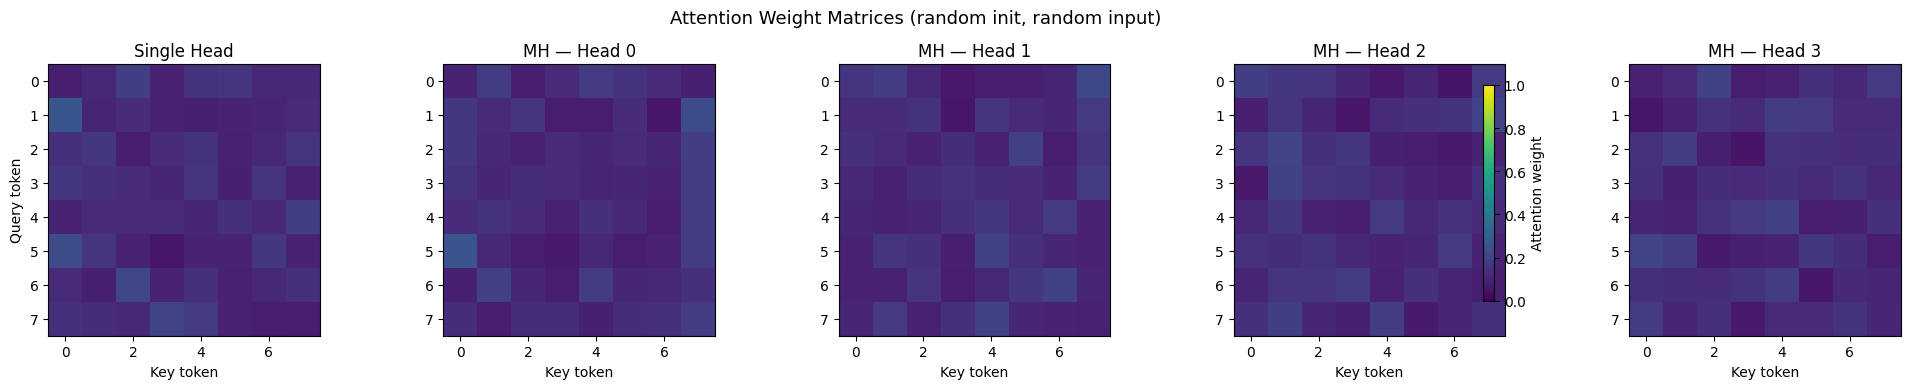

In [6]:
import matplotlib.pyplot as plt

torch.manual_seed(123)
x = torch.randn(1, 8, 64)

sa = SelfAttention(embed_dim=64)
_ = sa(x)

mhsa = MultiHeadSelfAttention(embed_dim=64, num_heads=4)
_ = mhsa(x)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

axes[0].imshow(sa.attention_weights[0].detach().numpy(), cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Single Head")
axes[0].set_xlabel("Key token")
axes[0].set_ylabel("Query token")

for h in range(4):
    im = axes[h + 1].imshow(
        mhsa.attention_weights[0, h].detach().numpy(), cmap="viridis", vmin=0, vmax=1
    )
    axes[h + 1].set_title(f"MH — Head {h}")
    axes[h + 1].set_xlabel("Key token")

fig.colorbar(im, ax=axes, shrink=0.8, label="Attention weight")
fig.suptitle("Attention Weight Matrices (random init, random input)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Aspect | Single-Head | Multi-Head ($H$ heads) |
|---|---|---|
| Q, K, V projection | $W_Q, W_K, W_V \in \mathbb{R}^{D \times D}$ | Same, but reshaped to $H$ sub-spaces of size $d_k = D/H$ |
| Attention weights | $(B, T, T)$ | $(B, H, T, T)$ |
| Expressiveness | One global attention pattern | $H$ independent patterns — can capture diverse relationships |
| Output | $YW_O$ | $\text{Concat}(\text{heads})\, W_O$ |

Both implementations were verified to match PyTorch's `nn.MultiheadAttention` up to floating-point precision (~1e-6).